# Decision Tree Training Notebook

This notebook follows the same workflow as the Python training script.
The only model-specific change is the classifier used at the end.

In [3]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from sklearn.tree import DecisionTreeClassifier

ROOT_DIR = Path.cwd().resolve().parent.parent
PYTHON_DIR = ROOT_DIR / "python"
if str(PYTHON_DIR) not in sys.path:
    sys.path.append(str(PYTHON_DIR))

from common import (  # noqa: E402
    CLASS_ORDER,
    coerce_feature_types,
    evaluate_predictions,
    load_tabular_file,
    build_preprocessor,
    split_feature_columns,
    infer_numeric_like_columns,
    standardize_columns,
    find_column,
    clean_rating_label,
    create_rating_group,
    IDENTIFIER_ALIASES,
    TARGET_ALIASES,
)

# Auto-detect the first CSV or Excel file in the data/ directory.
_data_dir = ROOT_DIR / "data"
_candidates = sorted(
    list(_data_dir.glob("*.csv")) + list(_data_dir.glob("*.xlsx")) + list(_data_dir.glob("*.xls"))
)
if not _candidates:
    raise FileNotFoundError(
        f"No CSV or Excel file found in {_data_dir}. ",
        "Please place your dataset there and re-run this cell.",
    )
DATA_PATH = _candidates[0]
print(f"Using dataset: {DATA_PATH}")
print("Imports ready")

C:\Users\winnie\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using dataset: C:\Users\winnie\OneDrive - Republic Polytechnic\Documents\FYP\New-Code\data\set A corporate_rating.csv
Imports ready


In [4]:
# Step 1: Load the dataset.
raw_df = load_tabular_file(str(DATA_PATH))
df = standardize_columns(raw_df)
print(df.shape)
df.head()

(2029, 31)


,Rating,Name,Symbol,Rating Agency Name,Date,Sector,currentRatio,quickRatio,cashRatio,daysOfSalesOutstanding,...,effectiveTaxRate,freeCashFlowOperatingCashFlowRatio,freeCashFlowPerShare,cashPerShare,companyEquityMultiplier,ebitPerRevenue,enterpriseValueMultiple,operatingCashFlowPerShare,operatingCashFlowSalesRatio,payablesTurnover
0,A,Whirlpool Corporation,WHR,Egan-Jones Ratings Company,11/27/2015,Consumer Durables,0.945894,0.426395,0.099690,44.203245,...,0.202716,0.437551,6.810673,9.809403,4.008012,0.049351,7.057088,15.565438,0.058638,3.906655
1,BBB,Whirlpool Corporation,WHR,Egan-Jones Ratings Company,2/13/2014,Consumer Durables,1.033559,0.498234,0.203120,38.991156,...,0.074155,0.541997,8.625473,17.402270,3.156783,0.048857,6.460618,15.914250,0.067239,4.002846
2,BBB,Whirlpool Corporation,WHR,Fitch Ratings,3/6/2015,Consumer Durables,0.963703,0.451505,0.122099,50.841385,...,0.214529,0.513185,9.693487,13.103448,4.094575,0.044334,10.491970,18.888889,0.074426,3.483510
3,BBB,Whirlpool Corporation,WHR,Fitch Ratings,6/15/2012,Consumer Durables,1.019851,0.510402,0.176116,41.161738,...,1.816667,-0.147170,-1.015625,14.440104,3.630950,-0.012858,4.080741,6.901042,0.028394,4.581150
4,BBB,Whirlpool Corporation,WHR,Standard & Poor's Ratings Services,10/24/2016,Consumer Durables,0.957844,0.495432,0.141608,47.761126,...,0.166966,0.451372,7.135348,14.257556,4.012780,0.053770,8.293505,15.808147,0.058065,3.857790


In [5]:
# Step 2: Check missing values and duplicates.
missing_values = df.isna().sum().sort_values(ascending=False)
duplicate_rows = int(df.duplicated().sum())
print(missing_values[missing_values > 0])
print("Duplicate rows:", duplicate_rows)

Series([], dtype: int64)
Duplicate rows: 0


In [6]:
# Step 3: Create the RatingGroup target.
rating_column = find_column(df, TARGET_ALIASES)
if rating_column is None:
    raise ValueError("No rating column found in the dataset.")

working_df = df.copy()
working_df[rating_column] = working_df[rating_column].apply(clean_rating_label)
working_df["RatingGroup"] = working_df[rating_column].apply(create_rating_group)
working_df = working_df.dropna(subset=["RatingGroup"]).copy()

identifier_columns = []
for alias in IDENTIFIER_ALIASES:
    found = find_column(working_df, [alias])
    if found and found not in identifier_columns:
        identifier_columns.append(found)

if rating_column not in identifier_columns:
    identifier_columns.append(rating_column)

working_df = working_df.drop(columns=identifier_columns, errors="ignore")
working_df = infer_numeric_like_columns(working_df, exclude_columns=["RatingGroup"])
print(working_df["RatingGroup"].value_counts())

RatingGroup
Speculative        792
Investment-Low     671
Investment-High    494
Distressed          72
Name: count, dtype: int64


In [7]:
# Step 4: Select features and prepare the training data.
feature_columns = [column for column in working_df.columns if column != "RatingGroup"]
numeric_columns, categorical_columns = split_feature_columns(working_df, "RatingGroup", [])
X = working_df[feature_columns].copy()
X = coerce_feature_types(X, numeric_columns, categorical_columns)
y = working_df["RatingGroup"].copy()
print("Numeric columns:", numeric_columns)
print("Categorical columns:", categorical_columns)

Numeric columns: ['currentRatio', 'quickRatio', 'cashRatio', 'daysOfSalesOutstanding', 'netProfitMargin', 'pretaxProfitMargin', 'grossProfitMargin', 'operatingProfitMargin', 'returnOnAssets', 'returnOnCapitalEmployed', 'returnOnEquity', 'assetTurnover', 'fixedAssetTurnover', 'debtEquityRatio', 'debtRatio', 'effectiveTaxRate', 'freeCashFlowOperatingCashFlowRatio', 'freeCashFlowPerShare', 'cashPerShare', 'companyEquityMultiplier', 'ebitPerRevenue', 'enterpriseValueMultiple', 'operatingCashFlowPerShare', 'operatingCashFlowSalesRatio', 'payablesTurnover']
Categorical columns: ['Sector']


In [8]:
# Step 5: Split the dataset and train the model.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.30,
    random_state=42,
    stratify=y_encoded,
)

pipeline = Pipeline(
    steps=[
        ("preprocessor", build_preprocessor(numeric_columns, categorical_columns)),
        ("model", DecisionTreeClassifier(random_state=42)),
    ]
)
pipeline.fit(X_train, y_train)
print("Model trained")

Model trained


In [9]:
# Step 6: Evaluate the trained model.
y_pred = pipeline.predict(X_test)
y_test_labels = label_encoder.inverse_transform(y_test)
y_pred_labels = label_encoder.inverse_transform(y_pred.astype(int))
metrics = evaluate_predictions(y_test_labels, y_pred_labels, CLASS_ORDER)
print(metrics["accuracy"])
print(metrics["classification_report_text"])


0.5500821018062397
                 precision    recall  f1-score   support

Investment-High       0.51      0.58      0.54       148
 Investment-Low       0.52      0.48      0.50       201
    Speculative       0.62      0.61      0.62       238
     Distressed       0.33      0.32      0.33        22

       accuracy                           0.55       609
      macro avg       0.50      0.50      0.50       609
   weighted avg       0.55      0.55      0.55       609



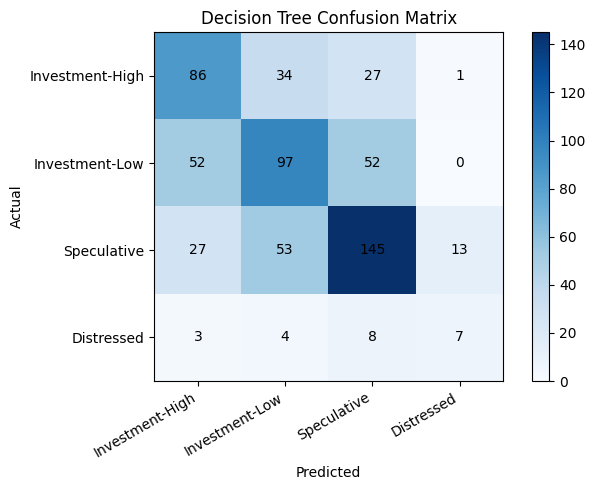

In [10]:
# Step 7: Show the confusion matrix.
cm = np.array(metrics["confusion_matrix"])
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(CLASS_ORDER)))
ax.set_yticks(range(len(CLASS_ORDER)))
ax.set_xticklabels(CLASS_ORDER, rotation=30, ha="right")
ax.set_yticklabels(CLASS_ORDER)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Decision Tree Confusion Matrix")

for row_index in range(cm.shape[0]):
    for column_index in range(cm.shape[1]):
        ax.text(
            column_index,
            row_index,
            cm[row_index, column_index],
            ha="center",
            va="center",
            color="black",
        )

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


## Min-Max Normalization

Min-Max normalization places numeric values within a fixed range, usually 0 to 1. The scaler is fit on `X_train` only, then applied to both `X_train` and `X_test`.


             Scenario  Accuracy  Weighted F1  Macro F1
             Baseline  0.550082     0.549774  0.496405
Min-Max Normalization  0.545156     0.546688  0.460789
                 precision    recall  f1-score   support

Investment-High       0.55      0.59      0.57       148
 Investment-Low       0.53      0.51      0.52       201
    Speculative       0.60      0.58      0.59       238
     Distressed       0.15      0.18      0.16        22

       accuracy                           0.55       609
      macro avg       0.46      0.47      0.46       609
   weighted avg       0.55      0.55      0.55       609



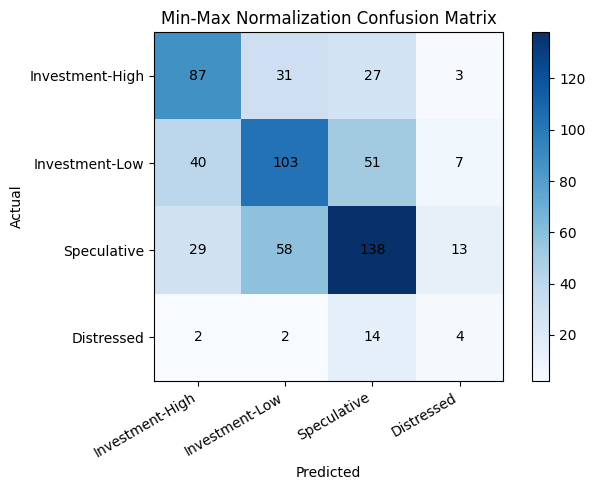

In [11]:
baseline_metrics = dict(metrics)

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

try:
    one_hot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    one_hot = OneHotEncoder(handle_unknown="ignore", sparse=False)

X_train_minmax, X_test_minmax, y_train_minmax, y_test_minmax = train_test_split(
    X.copy(),
    y_encoded.copy(),
    test_size=0.30,
    random_state=42,
    stratify=y_encoded,
)

numeric_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", MinMaxScaler()),
    ]
)

categorical_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", one_hot),
    ]
)

minmax_preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipe, numeric_columns),
        ("categorical", categorical_pipe, categorical_columns),
    ],
    remainder="drop",
)

minmax_pipeline = Pipeline(
    steps=[
        ("preprocessor", minmax_preprocessor),
        ("model", DecisionTreeClassifier(random_state=42)),
    ]
)
minmax_pipeline.fit(X_train_minmax, y_train_minmax)

minmax_pred = minmax_pipeline.predict(X_test_minmax)
y_test_labels = label_encoder.inverse_transform(y_test_minmax)
y_pred_labels = label_encoder.inverse_transform(minmax_pred.astype(int))
minmax_metrics = evaluate_predictions(y_test_labels, y_pred_labels, CLASS_ORDER)

comparison_table = pd.DataFrame(
    [
        {
            "Scenario": "Baseline",
            "Accuracy": baseline_metrics["accuracy"],
            "Weighted F1": baseline_metrics["weighted_f1"],
            "Macro F1": baseline_metrics["macro_f1"],
        },
        {
            "Scenario": "Min-Max Normalization",
            "Accuracy": minmax_metrics["accuracy"],
            "Weighted F1": minmax_metrics["weighted_f1"],
            "Macro F1": minmax_metrics["macro_f1"],
        },
    ]
)

print(comparison_table.to_string(index=False))
print(minmax_metrics["classification_report_text"])

cm = np.array(minmax_metrics["confusion_matrix"])
fig, ax = plt.subplots(figsize=(7, 5))
image = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(CLASS_ORDER)))
ax.set_yticks(range(len(CLASS_ORDER)))
ax.set_xticklabels(CLASS_ORDER, rotation=30, ha="right")
ax.set_yticklabels(CLASS_ORDER)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Min-Max Normalization Confusion Matrix")

for row_index in range(cm.shape[0]):
    for column_index in range(cm.shape[1]):
        ax.text(column_index, row_index, cm[row_index, column_index], ha="center", va="center", color="black")

fig.colorbar(image, ax=ax)
plt.tight_layout()
plt.show()


## Experiment 7: Hyperparameter Tuning

This experiment uses the final selected preprocessing flow, fits `GridSearchCV` only on `X_train`, and evaluates the best estimator on the untouched `X_test`.


Best parameters:
{'model__criterion': 'gini', 'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5}

Best cross-validation accuracy: 0.505634

Untuned vs tuned metrics:
Scenario  Accuracy  Weighted F1  Macro F1
 Untuned  0.550082     0.549774  0.496405
   Tuned  0.541872     0.544431  0.464249

Tuned classification report:
                 precision    recall  f1-score   support

Investment-High       0.51      0.58      0.54       148
 Investment-Low       0.53      0.50      0.52       201
    Speculative       0.62      0.58      0.60       238
     Distressed       0.17      0.23      0.20        22

       accuracy                           0.54       609
      macro avg       0.46      0.47      0.46       609
   weighted avg       0.55      0.54      0.54       609



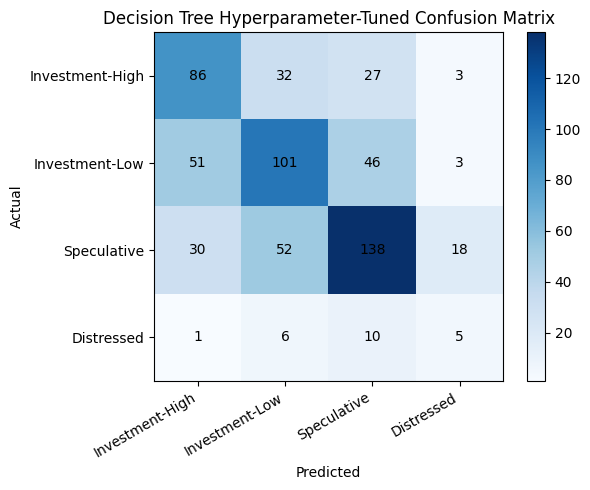

Conclusion: Reject - tuning did not improve the untuned test performance.


In [12]:
# Experiment 7: Hyperparameter Tuning
from sklearn.base import clone
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline

final_preprocessor = build_preprocessor(numeric_columns, categorical_columns)
base_model = clone(pipeline.named_steps["model"])

untuned_pipeline = Pipeline(
    steps=[
        ("preprocessor", build_preprocessor(numeric_columns, categorical_columns)),
        ("model", clone(base_model)),
    ]
)
untuned_pipeline.fit(X_train, y_train)
untuned_pred = untuned_pipeline.predict(X_test)
untuned_pred_labels = label_encoder.inverse_transform(untuned_pred.astype(int))
untuned_metrics = evaluate_predictions(y_test_labels, untuned_pred_labels, CLASS_ORDER)

search = GridSearchCV(
    estimator=Pipeline(
        steps=[
            ("preprocessor", build_preprocessor(numeric_columns, categorical_columns)),
            ("model", clone(base_model)),
        ]
    ),
    param_grid={
    "model__criterion": ["gini", "entropy"],
    "model__max_depth": [None, 5, 10, 15],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
},
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="accuracy",
    n_jobs=-1,
    refit=True,
)
search.fit(X_train, y_train)

best_pipeline = search.best_estimator_
best_pred = best_pipeline.predict(X_test)
best_pred_labels = label_encoder.inverse_transform(best_pred.astype(int))
tuned_metrics = evaluate_predictions(y_test_labels, best_pred_labels, CLASS_ORDER)

print("Best parameters:")
print(search.best_params_)
print()
print(f"Best cross-validation accuracy: {search.best_score_:.6f}")
print()

comparison = pd.DataFrame(
    [
        {
            "Scenario": "Untuned",
            "Accuracy": untuned_metrics["accuracy"],
            "Weighted F1": untuned_metrics["weighted_f1"],
            "Macro F1": untuned_metrics["macro_f1"],
        },
        {
            "Scenario": "Tuned",
            "Accuracy": tuned_metrics["accuracy"],
            "Weighted F1": tuned_metrics["weighted_f1"],
            "Macro F1": tuned_metrics["macro_f1"],
        },
    ]
)
print("Untuned vs tuned metrics:")
print(comparison.to_string(index=False))
print()
print("Tuned classification report:")
print(tuned_metrics["classification_report_text"])

cm = np.array(tuned_metrics["confusion_matrix"])
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(CLASS_ORDER)))
ax.set_yticks(range(len(CLASS_ORDER)))
ax.set_xticklabels(CLASS_ORDER, rotation=30, ha="right")
ax.set_yticklabels(CLASS_ORDER)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Decision Tree Hyperparameter-Tuned Confusion Matrix")

for row_index in range(cm.shape[0]):
    for column_index in range(cm.shape[1]):
        ax.text(column_index, row_index, cm[row_index, column_index], ha="center", va="center", color="black")

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

if tuned_metrics["accuracy"] > untuned_metrics["accuracy"] or (
    tuned_metrics["accuracy"] == untuned_metrics["accuracy"]
    and tuned_metrics["weighted_f1"] >= untuned_metrics["weighted_f1"]
):
    conclusion = "Keep"
    reason = "tuning improved or matched the untuned test performance."
else:
    conclusion = "Reject"
    reason = "tuning did not improve the untuned test performance."

print(f"Conclusion: {conclusion} - {reason}")


## Experiment 8: Min-Max Normalization + Hyperparameter Tuning

This experiment applies Min-Max normalization first, then runs `GridSearchCV` on the normalized training data only. The scaler and model are fit inside the cross-validation pipeline, so `X_test` stays untouched.


Best parameters:
{'model__criterion': 'entropy', 'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}

Best cross-validation accuracy: 0.509155

Untuned vs tuned Min-Max metrics:
       Scenario  Accuracy  Weighted F1  Macro F1
Untuned Min-Max  0.545156     0.546688  0.460789
  Tuned Min-Max  0.555008     0.551224  0.462014

Tuned Min-Max classification report:
                 precision    recall  f1-score   support

Investment-High       0.55      0.57      0.56       148
 Investment-Low       0.50      0.48      0.49       201
    Speculative       0.62      0.65      0.64       238
     Distressed       0.21      0.14      0.17        22

       accuracy                           0.56       609
      macro avg       0.47      0.46      0.46       609
   weighted avg       0.55      0.56      0.55       609



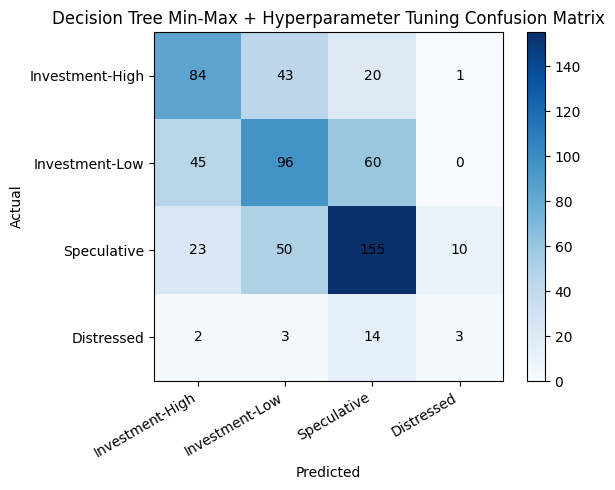

Conclusion: Keep - the tuned Min-Max pipeline improved or matched the untuned Min-Max test performance.


In [13]:
# Experiment 8: Min-Max Normalization + Hyperparameter Tuning
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

try:
    one_hot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    one_hot = OneHotEncoder(handle_unknown="ignore", sparse=False)

minmax_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", MinMaxScaler())]), numeric_columns),
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", one_hot)]), categorical_columns),
    ]
)

base_model = clone(pipeline.named_steps["model"])

untuned_minmax_pipeline = Pipeline(
    steps=[
        ("preprocessor", minmax_preprocessor),
        ("model", clone(base_model)),
    ]
)
untuned_minmax_pipeline.fit(X_train, y_train)
untuned_minmax_pred = untuned_minmax_pipeline.predict(X_test)
untuned_minmax_pred_labels = label_encoder.inverse_transform(untuned_minmax_pred.astype(int))
untuned_minmax_metrics = evaluate_predictions(y_test_labels, untuned_minmax_pred_labels, CLASS_ORDER)

search = GridSearchCV(
    estimator=Pipeline(
        steps=[
            ("preprocessor", minmax_preprocessor),
            ("model", clone(base_model)),
        ]
    ),
    param_grid={
    "model__criterion": ["gini", "entropy"],
    "model__max_depth": [None, 5, 10, 15],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
},
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="accuracy",
    n_jobs=-1,
    refit=True,
)
search.fit(X_train, y_train)

best_pipeline = search.best_estimator_
best_pred = best_pipeline.predict(X_test)
best_pred_labels = label_encoder.inverse_transform(best_pred.astype(int))
tuned_minmax_metrics = evaluate_predictions(y_test_labels, best_pred_labels, CLASS_ORDER)

print("Best parameters:")
print(search.best_params_)
print()
print(f"Best cross-validation accuracy: {search.best_score_:.6f}")
print()

comparison = pd.DataFrame(
    [
        {
            "Scenario": "Untuned Min-Max",
            "Accuracy": untuned_minmax_metrics["accuracy"],
            "Weighted F1": untuned_minmax_metrics["weighted_f1"],
            "Macro F1": untuned_minmax_metrics["macro_f1"],
        },
        {
            "Scenario": "Tuned Min-Max",
            "Accuracy": tuned_minmax_metrics["accuracy"],
            "Weighted F1": tuned_minmax_metrics["weighted_f1"],
            "Macro F1": tuned_minmax_metrics["macro_f1"],
        },
    ]
)
print("Untuned vs tuned Min-Max metrics:")
print(comparison.to_string(index=False))
print()
print("Tuned Min-Max classification report:")
print(tuned_minmax_metrics["classification_report_text"])

cm = np.array(tuned_minmax_metrics["confusion_matrix"])
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(CLASS_ORDER)))
ax.set_yticks(range(len(CLASS_ORDER)))
ax.set_xticklabels(CLASS_ORDER, rotation=30, ha="right")
ax.set_yticklabels(CLASS_ORDER)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Decision Tree Min-Max + Hyperparameter Tuning Confusion Matrix")

for row_index in range(cm.shape[0]):
    for column_index in range(cm.shape[1]):
        ax.text(column_index, row_index, cm[row_index, column_index], ha="center", va="center", color="black")

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

if tuned_minmax_metrics["accuracy"] > untuned_minmax_metrics["accuracy"] or (
    tuned_minmax_metrics["accuracy"] == untuned_minmax_metrics["accuracy"]
    and tuned_minmax_metrics["weighted_f1"] >= untuned_minmax_metrics["weighted_f1"]
):
    conclusion = "Keep"
    reason = "the tuned Min-Max pipeline improved or matched the untuned Min-Max test performance."
else:
    conclusion = "Reject"
    reason = "the tuned Min-Max pipeline did not improve the untuned Min-Max test performance."

print(f"Conclusion: {conclusion} - {reason}")


## Explainable AI: SHAP Feature Importance

This section explains the final model trained using Min-Max normalization and hyperparameter tuning.

Final model used for SHAP:
DecisionTreeClassifier(criterion='entropy', random_state=42)

Top SHAP features:


,Feature,Mean Absolute SHAP Value,Rank
0,pretaxProfitMargin,0.071067,1
1,netProfitMargin,0.063970,2
2,operatingCashFlowSalesRatio,0.052708,3
3,enterpriseValueMultiple,0.034059,4
4,cashRatio,0.032721,5
5,debtRatio,0.029206,6
6,effectiveTaxRate,0.025857,7
7,quickRatio,0.023927,8
8,currentRatio,0.022155,9
9,daysOfSalesOutstanding,0.019783,10


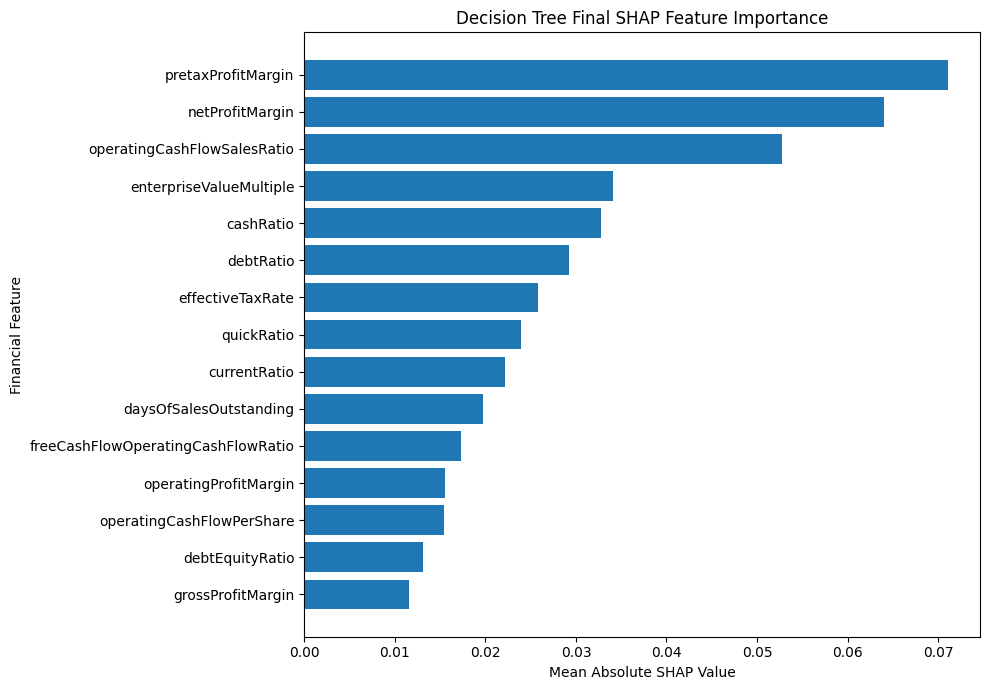

In [14]:
# Final SHAP Feature Importance
# This explains the final Min-Max normalized and hyperparameter-tuned model.

final_pipeline = best_pipeline

# Extract the fitted preprocessing component and fitted model.
final_preprocessor = final_pipeline.named_steps["preprocessor"]
final_model = final_pipeline.named_steps["model"]

# Apply the already-fitted preprocessing steps.
X_train_transformed = final_preprocessor.transform(X_train)
X_test_transformed = final_preprocessor.transform(X_test)

# Convert sparse matrices into normal NumPy arrays.
if hasattr(X_train_transformed, "toarray"):
    X_train_transformed = X_train_transformed.toarray()

if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

# Retrieve the transformed feature names.
feature_names = final_preprocessor.get_feature_names_out()

# Remove prefixes such as num__ and cat__ from the displayed names.
display_feature_names = np.array(
    [str(name).split("__", 1)[-1] for name in feature_names]
)

# Use a fixed sample size to reduce SHAP processing time.
background_size = min(100, X_train_transformed.shape[0])
explanation_size = min(100, X_test_transformed.shape[0])

background_data = X_train_transformed[:background_size]
explanation_data = X_test_transformed[:explanation_size]

# Select the correct SHAP explainer.
if final_model.__class__.__name__ == "LogisticRegression":
    shap_explainer = shap.LinearExplainer(
        final_model,
        background_data,
        feature_names=feature_names
    )
else:
    shap_explainer = shap.TreeExplainer(final_model)

# Calculate SHAP values.
shap_result = shap_explainer(explanation_data)

# Support different SHAP output formats.
if isinstance(shap_result, list):
    shap_array = np.stack(
        [np.asarray(class_values) for class_values in shap_result],
        axis=-1
    )
elif hasattr(shap_result, "values"):
    shap_array = np.asarray(shap_result.values)
else:
    shap_array = np.asarray(shap_result)

# Calculate mean absolute SHAP values.
if shap_array.ndim == 2:
    mean_abs_shap = np.mean(np.abs(shap_array), axis=0)

elif shap_array.ndim == 3:
    if shap_array.shape[1] == len(feature_names):
        # Shape: observations, features, classes
        mean_abs_shap = np.mean(np.abs(shap_array), axis=(0, 2))

    elif shap_array.shape[2] == len(feature_names):
        # Shape: classes, observations, features
        mean_abs_shap = np.mean(np.abs(shap_array), axis=(0, 1))

    else:
        raise ValueError(
            f"Unexpected SHAP shape: {shap_array.shape}"
        )
else:
    raise ValueError(
        f"Unsupported SHAP dimensions: {shap_array.ndim}"
    )

# Create the ranked feature importance table.
shap_importance = pd.DataFrame(
    {
        "Feature": display_feature_names,
        "Mean Absolute SHAP Value": mean_abs_shap
    }
)

shap_importance = shap_importance.sort_values(
    "Mean Absolute SHAP Value",
    ascending=False
).reset_index(drop=True)

shap_importance["Rank"] = shap_importance.index + 1
shap_importance["Mean Absolute SHAP Value"] = (
    shap_importance["Mean Absolute SHAP Value"].round(6)
)

print("Final model used for SHAP:")
print(final_model)

print("\nTop SHAP features:")
display(shap_importance.head(15))

# Set the model name for the chart.
model_title_names = {
    "DecisionTreeClassifier": "Decision Tree",
    "RandomForestClassifier": "Random Forest",
    "XGBClassifier": "XGBoost",
    "LogisticRegression": "Logistic Regression"
}

model_title = model_title_names.get(
    final_model.__class__.__name__,
    final_model.__class__.__name__
)

# Plot the 15 most influential features.
top_features = shap_importance.head(15).sort_values(
    "Mean Absolute SHAP Value",
    ascending=True
)

plt.figure(figsize=(10, 7))
plt.barh(
    top_features["Feature"],
    top_features["Mean Absolute SHAP Value"]
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Financial Feature")
plt.title(f"{model_title} Final SHAP Feature Importance")
plt.tight_layout()
plt.show()